<a href="https://colab.research.google.com/github/annakiryan/DLS-homeworks-2025/blob/main/hw_7_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Детекция объектов</b></h3>

В этом домашнем задании мы продолжим работу над детектором из семинара, поэтому при необходимости можете заимствовать оттуда любой код.

Домашнее задание можно разделить на следующие части:

* Переделываем модель [4]
  * Backbone[1],
  * Neck [2],
  * Head [1]
* Label assignment [3]:
  * TAL [3]
* Лоссы [1]:
  * CIoU loss [1]
* Кто больше? [5]
  * 0.05 mAP [1]
  * 0.1 mAP  [2]
  * 0.2 mAP [5]

**Максимальный балл:** 10 баллов. (+3 балла бонус).

In [1]:
! pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 22.4 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import pandas as pd
import albumentations as A
import timm

from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset
from albumentations.pytorch.transforms import ToTensorV2

In [3]:
import math
from functools import partial
from collections import Counter, defaultdict

import io
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import timm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from PIL import Image
from tqdm.auto import tqdm
from torchvision import transforms
from torchvision.ops import nms, box_iou
from torchvision.models.detection.anchor_utils import AnchorGenerator

from torchmetrics.detection import MeanAveragePrecision

In [4]:
device = "cuda"

### Загрузка данных

Мы продолжаем работу с датасетом из семинара - Halo infinite ([сслыка](https://universe.roboflow.com/graham-doerksen/halo-infinite-angel-aim)). Загрузка данных и создание датасета полностью скопированы из семинара.

Сначала загружаем данные

In [5]:
splits = {'train': 'data/train-00000-of-00001-0d6632d599c29801.parquet',
          'validation': 'data/validation-00000-of-00001-c6b77a557eeedd52.parquet',
          'test': 'data/test-00000-of-00001-866d29d8989ea915.parquet'}
df_train = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["train"])
df_val = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["validation"])
df_test = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["test"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Создаем датасет для предобработки данных

In [6]:
class HaloDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        df_objects = pd.json_normalize(dataframe['objects'])[["bbox", "category"]]
        df_images = pd.json_normalize(dataframe['image'])[["bytes"]]
        self.data = dataframe[["image_id"]].join(df_objects).join(df_images)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        """Загружаем данные и разметку для объекта с индексом `idx`.

        labels: List[int] Набор классов для каждого ббокса,
        boxes: List[List[int]] Набор ббоксов в формате (x_min, y_min, w, h).
        """
        row = self.data.iloc[idx]
        image = Image.open(io.BytesIO(row["bytes"]))
        image = np.array(image)

        target = {}
        labels = row["category"]
        # Вычитаем единицу чтобы классы начинались с нуля
        labels = [label - 1 for label in labels]

        # для удобства сразу переводим в формат xyxy
        boxes = []
        for (x, y, w, h) in row["bbox"]:
          boxes.append((x, y, x + w, y + h))

        if self.transform is not None:
            boxes = np.array(boxes, dtype=np.float32)
            transformed = self.transform(image=image, bboxes=boxes, labels=labels)
            image, boxes, labels = transformed["image"], transformed["bboxes"], transformed["labels"]
        else:
            image = transforms.ToTensor()(image)

        target["image_id"] = row["image_id"]
        target['boxes'] = torch.tensor(np.array(boxes), dtype=torch.float32)
        target['labels'] = torch.tensor(labels, dtype=torch.int64)
        return image, target

def collate_fn(batch):
    imgs, targets = zip(*batch)
    imgs = torch.stack(imgs)
    return imgs, list(targets)

Чтобы модель не переобучалась, можно добавить больше аугментаций, весь список можно посмотреть тут [[ссылка](https://explore.albumentations.ai/)].

Какие можно использовать аугментации?
* Добавить зум `RandomResizedCrop`,
* Сделать цветовые аугментации типа `RandomBrightnessContrast` и/или `HueSaturationValue`,
* Добавить шум `GaussNoise`,
* Вырезать случайные части изображения `CoarseDropout`,
* И любые другие!

Аугментации можно комбинировать посредствам `A.OneOf`, `A.SomeOf` или `A.RandomOrder`.

Хоть аугментации ограничиваются только вашей фантазией, перед обучением советуем посмотреть на результат преобразований и убедиться, что изображение ещё поддается детекции:)

In [7]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = A.Compose(
    [
        A.RandomBrightnessContrast(p=0.2),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    bbox_params=A.BboxParams(
        format='pascal_voc',
        min_area=0,
        min_visibility=0,
        label_fields=['labels']
    )
)

test_transform = A.Compose(
    [
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    bbox_params=A.BboxParams(
        format='pascal_voc',
        label_fields=['labels']
    )
)

/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


Не забываем инициализировать наш датасет

In [8]:
train_dataset = HaloDataset(df_train, transform=train_transform)
val_dataset = HaloDataset(df_val, transform=test_transform)
test_dataset = HaloDataset(df_test, transform=test_transform)

In [37]:
batch_size = 8

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn
)

## Переделываем модель [4 балла]

В семинаре мы реализовали самый базовый детектор, а сейчас настало время его улучшать.

### Backbone [1 балл]

Хорошей практикой считается размораживать несколько последних слоев в backbone, это позволяет немного улучшить качество модели. Давайте улушчим класс Backbone из лекции, добавив ему возможность разморозки __k__ последних слоев или блоков (на ваш выбор).

In [10]:
def unfreeze_last_n_modules(model, n):
  modules = list(model.children())
  for module in modules[-n:]:
    for param in module.parameters():
      param.requires_grad = True

In [11]:
class Backbone(nn.Module):
  def __init__(self, model_name="efficientnet_b0", out_indices=(-1, -2, -3, -4), to_unfreeze=2):
    super().__init__()

    self.backbone = timm.create_model(model_name=model_name, pretrained=True, features_only=True, out_indices=out_indices)

    if to_unfreeze > 0:
      unfreeze_last_n_modules(self.backbone, to_unfreeze)

  def forward(self, x):
    return self.backbone(x)

In [12]:
backbone = Backbone()
x = torch.randn(1,3,640,640)
feats = backbone(x)
for f in feats:
  print(f.shape)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

torch.Size([1, 24, 160, 160])
torch.Size([1, 40, 80, 80])
torch.Size([1, 112, 40, 40])
torch.Size([1, 320, 20, 20])


### NECK [2 балла]

Следующее улучшение коснется шеи. Предлагаем реализовать знакомую из лекции архитектуру FPN.

#### Feature Pyramid Network

<center><img src="https://user-images.githubusercontent.com/57972646/69858594-b14a6c00-12d5-11ea-8c3e-3c17063110d3.png"/></center>


* [Feature Pyramid Networks for Object Detection](https://arxiv.org/abs/1612.03144)

Она состоит из top-down пути, в котором происходит 2 вещи:
1. Увеличивается пространственная размерность фичей,
2. С помощью скипконнекшеннов, добавляются фичи из backbone модели.

Для увеличения пространственной размерности используется __nearest neighbor upsampling__, а фичи из шеи и бекбоуна суммируются.

__TIPS__:
* Можете использовать базовые классы из лекции,
* Воспользуйтесь AnchorGenerator-ом, чтобы создавать якоря сразу для нескольких выходов,
* Не забудьте использовать nn.ModuleList, если захотите сделать динамическое количество голов у модели,
* Также, можно добавить доп конволюцию (3х3 с паддингом) у каждого выхода шеи.

In [13]:
import torch.nn as nn

class Neck(nn.Module):
    def __init__(self, in_channels=[24, 40, 112, 320], out_channels=256):
        super().__init__()

        self.lateral_convs = nn.ModuleList([
            nn.Conv2d(c, out_channels, kernel_size=1)
            for c in in_channels
        ])

        self.smooth_convs = nn.ModuleList([
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
            for _ in in_channels
        ])

    def forward(self, features):
        C2, C3, C4, C5 = features

        L2 = self.lateral_convs[0](C2)
        L3 = self.lateral_convs[1](C3)
        L4 = self.lateral_convs[2](C4)
        L5 = self.lateral_convs[3](C5)

        P5 = L5
        P4 = L4 + F.interpolate(P5, scale_factor=2, mode='nearest')
        P3 = L3 + F.interpolate(P4, scale_factor=2, mode='nearest')
        P2 = L2 + F.interpolate(P3, scale_factor=2, mode='nearest')

        P2 = self.smooth_convs[0](P2)
        P3 = self.smooth_convs[1](P3)
        P4 = self.smooth_convs[2](P4)
        P5 = self.smooth_convs[3](P5)

        return [P2, P3, P4, P5]

### Head [1 балл]

В качестве головы можно выбрать __один из двух__ вариантов:

#### 1. Decoupled Head

Реализовать Decoupled Head из [YOLOX](https://arxiv.org/abs/2107.08430).
<center><img src="https://i.ibb.co/BVtBR2R3/Decoupled-head.jpg"/></center>

**TIP**: Возьмите за основу голову из семинара, тк она сильно похожа на Decoupled Head.

Изменять количество параметров у шей на разных уровнях не обязательно.

#### 2. Confidence score free head

Нужно взять за основу голову из семинара и полностью убрать предсказание confidence score. Чтобы модель предсказывала только 2 группы: ббоксы и классы.

Есть следующие способы удаления confidence score:
* Добавление нового класса ФОН. Обычно его обозначают нулевым классом.
* Присваивание ббоксам БЕЗ объекта вектор из нулей в качестве таргета.

Выберете тот, который вам больше нравится и будьте внимательны при расчете лосса!

**Важно!** Удаление confidence score повлияет на следующие методы из семинара:
* target_assign
* ComputeLoss
* _filter_predictions

In [14]:
class Head(nn.Module):
  def __init__(self, num_classes=4, in_channels=256):
    super().__init__()

    self.cls_conv = nn.Sequential(
      nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
      nn.ReLU(),
      nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
      nn.ReLU()
    )

    self.cls_pred = nn.Conv2d(in_channels, num_classes, kernel_size=1)

    self.reg_conv = nn.Sequential(
      nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
      nn.ReLU(),
      nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
      nn.ReLU()
    )

    self.reg_pred = nn.Conv2d(in_channels, 4, kernel_size=1) # расстояния l, t, r, b от центра ячейки
    self.iou_pred = nn.Conv2d(in_channels, 1, kernel_size=1)


  def forward(self, x):
    cls_feat = self.cls_conv(x)
    cls_out = self.cls_pred(cls_feat)

    reg_feat = self.reg_conv(x)
    reg_out = self.reg_pred(reg_feat)
    iou_out = self.iou_pred(reg_feat)

    return cls_out, reg_out, iou_out

Теперь можно снова реализовать класс детектора с учетом всех частей выше!

Нам понадобятся вспомогательные функции: подсчет координат центров ячеек для каждой фичемапы, а также декодирование предсказанных отступов в формат xyxy

In [15]:
class Detector(nn.Module):
  def __init__(self, num_classes, fpn_channels=256, strides=[4,8,16,32]):
    super().__init__()

    self.backbone = Backbone()
    self.neck = Neck()
    self.heads = nn.ModuleList([
        Head(num_classes, fpn_channels)
        for _ in range(4)
    ])
    self.strides = strides

  def forward(self, x):
    features = self.backbone(x)
    features = self.neck(features)
    centers = self.generate_grids(features)

    cls_probs = []
    bboxes = []
    iou = []

    for f_map, center_map, head in zip(features, centers, self.heads):
      cls_out, reg_out, iou_out = head(f_map)

      decoded = self.decode_boxes(center_map, reg_out)

      cls_probs.append(cls_out)
      bboxes.append(decoded)
      iou.append(iou_out)

    return cls_probs, bboxes, iou, centers

  @torch.no_grad()
  def generate_grids(self, feature_maps):
    """
    feature_maps: список FPN-карт [P2,P3,P4,P5]
    Возвращает centers_per_level: список тензоров (HxWx2)
    Каждый центр хранит (cx, cy) в координатах исходного изображения
    """
    centers = []

    for f_map, stride in zip(feature_maps, self.strides):
        _, _, h, w = f_map.shape

        yv, xv = torch.meshgrid(
            torch.arange(h, device=f_map.device), torch.arange(w, device=f_map.device), indexing="ij"
        )
        xv = (xv + 0.5) * stride
        yv = (yv + 0.5) * stride

        centers.append(torch.stack([xv, yv], dim=-1))

    return centers

  def decode_boxes(self, centers, pred_offsets):
    B = pred_offsets.shape[0]
    H, W = centers.shape[:2]

    centers = centers.permute(2, 0, 1).unsqueeze(0)

    centers = centers.repeat(B, 1, 1, 1)

    cx = centers[:, 0]
    cy = centers[:, 1]

    l = pred_offsets[:, 0]
    t = pred_offsets[:, 1]
    r = pred_offsets[:, 2]
    b = pred_offsets[:, 3]

    x1 = cx - l
    y1 = cy - t
    x2 = cx + r
    y2 = cy + b

    return torch.stack([x1, y1, x2, y2], dim=1)

## Label assignment [3 балла]
В этой секции предлагается заменить функцию `assign_target` на более современный алгоритм который называется Task alignment learning.

Он описан в статье [TOOD](https://arxiv.org/abs/2108.07755) в секции 3.2. Для удобства вот его основные шаги:

1. Посчитать значение метрики для каждого предсказанного ббокса:
    
$$t = s^\alpha * u^\beta$$
    
где,
* $s$ — classification score, или вероятность принадлежности предсказанного ббокса к классу реального ббокса (**GT**);
* $u$ — IoU между предсказанным и реальным ббоксами;
* $\alpha,\ \beta$ — нормализационные константы, обычно $\alpha = 6.0, \ \beta = 1.0$.
    
2. Отфильтровать предсказания на основе **GT**.

    Для якорных детекторов, обычно, выбираются только те предсказания, центры якорей которых находятся внутри GT.
4. Для каждого **GT** выбрать несколько (обычно 5 или 13) самых подходящих предсказаний.
5. Если предсказание рассматривается в качестве подходящего для нескольких **GT** — выбрать **GT** с наибольшим пересечением по IoU.


**BAЖНО**: если будете использовать Runner из лекции, не забудьте поменять параметры  в `self.assign_target_method` в методе `_run_train_epoch`.

In [16]:
from torchvision.ops import box_iou

def TAL_assigner(
  cls_preds, # [N, num_classes]
  box_preds, # [N, 4]
  centers_xy, # [N, 2]
  gt_boxes, # [M, 4]
  gt_labels, # [M]
  alpha=6.0, beta=1.0, top_k=5
  ):

  N = cls_preds.shape[0]
  M = gt_boxes.shape[0]

  assigned_labels = torch.zeros(N, device=device, dtype=torch.int64)
  assigned_boxes  = torch.zeros((N, 4), device=device)
  assigned_scores = torch.zeros(N, device=device)

  if M == 0:
    return assigned_labels, assigned_boxes, assigned_scores

  iou = box_iou(box_preds, gt_boxes)

  prob = torch.softmax(cls_preds, dim=1)
  s = prob[:, gt_labels]

  t = (s ** alpha) * (iou ** beta)

  px = centers_xy[:, 0][:, None]
  py = centers_xy[:, 1][:, None]

  x1, y1, x2, y2 = gt_boxes.unbind(dim=1)

  inside = (px >= x1) & (px <= x2) & (py >= y1) & (py <= y2)
  t = t * inside.float()

  topk_idx = torch.topk(t, k=min(top_k, N), dim=0).indices

  assigned_to = torch.full((N,), -1, device=device, dtype=torch.int64)
  for gi in range(M):
    for idx in topk_idx[:, gi]:
      idx = idx.item()
      if t[idx, gi] == 0:
        continue
      if assigned_to[idx] != -1:
        old_gt = assigned_to[idx]
        if iou[idx, gi] > iou[idx, old_gt]:
          assigned_to[idx] = gi
      else:
        assigned_to[idx] = gi

  pos = assigned_to >= 0
  assigned_gt = assigned_to[pos]
  assigned_labels[pos] = gt_labels[assigned_gt]
  assigned_boxes[pos] = gt_boxes[assigned_gt]
  assigned_scores[pos] = t[pos, assigned_gt]

  return assigned_labels, assigned_boxes, assigned_scores

### DIoU [1]

Вместо SmoothL1, который используется в семинаре, реализуем лосс, основанный на пересечении ббоксов. В качестве тренировки давайте напишем Distance Intersection over Union (DIoU).

<center><img src=https://wikidocs.net/images/page/163613/Free_Fig_5.png></center>

Для его реализации разобъем задачу на части:

**1. Реализуем IoU:**

Пусть даны координаты для предсказанного ($B^p$) и истинного ($B^g$) ббоксов в формате XYXY или VOC PASCAL (левый верхний и правый нижний углы):

$B^p=(x^p_1, y^p_1, x^p_2, y^p_2)$, $B^g=(x^g_1, y^g_1, x^g_2, y^g_2)$, тогда алгоритм расчета будет следующий:

    1. Найдем площади обоих ббоксов:
$$ A^p = (x^p_2 - x^p_1) * (y^p_2 - y^p_1) $$
$$ A^g = (x^g_2 - x^g_1) * (y^g_2 - y^g_1) $$

    2. Посчитаем пересечение между ббоксами:

Тут мы предлагаем вам подумать как в общем виде можно расчитать размеры ббокса, который будет являться пересечением $B^p$ и $B^g$, а затем посчитать его площадь:

$$x^I_1 = \max(x^{p}_{1},\; x^{g}_{1})
\qquad \qquad y^I_1 = \max(y^{p}_{1},\; y^{g}_{1}) $$
$$x^I_2 = \min(x^{p}_{2},\; x^{g}_{2}) \qquad \qquad y^I_2 = \min(y^{p}_{2},\; y^{g}_{2})$$

В общем виде, площать будет записываться следующим образом:

Если $x^I_2 > x^I_1$ & $y^I_2 > y^I_1$, тогда:

$$I = (x^I_2 - x^I_1) * (y^I_2 - y^I_1)$$

Иначе, $I = 0$.

    3. Считаем объединение ббоксов.

Мы можем посчитать эту площадь как сумму площадей двух ббоксов минус площадь пересечения (тк мы считаем её два раз в сумме площадей):

$$U = A^p + A^g - I$$

    4. Вычисляем IoU.

$$IoU = \frac{I}{U}$$

**2. Посчитаем диагональ выпуклой оболочки:**

Для расчета диагонали, сначала выпишите координаты верхнего левого и правого нижнего углов. Подумайте, чему будут равны эти координаты в общем случае?

$$x^c_1 = \min(x^{p}_{1},\; x^{g}_{1}) \qquad \qquad y^c_1 = \min(y^{p}_{1},\; y^{g}_{1})$$
$$x^c_2 = \max(x^{p}_{2},\; x^{g}_{2})\qquad \qquad y^c_2 = \max(y^{p}_{2},\; y^{g}_{2})$$

Подсказка: Нарисуйте несколько вариантов пересечений предсказания и GT на бумажке, и выпишите координаты для выпуклой оболочки.

Тогда квадрат диагонали можно посчитать по формуле:

$$c^2 = (x^c_2 - x^c_1)^2 + (y^c_2 - y^c_1)^2$$

**3. Рассчитаем расстояние между цетрами ббоксов:**

Сначала находим координаты центров каждого из ббоксов (если ббоксы в формате YOLO, то и считать ничего не нужно), затем считаем Евклидово расстояние между центрами.

Найдем центры:

$$
x^{p}_{c} = \frac{x^{p}_{1} + x^{p}_{2} }{2}, \qquad
y^{p}_{c} = \frac{y^{p}_{1} + y^{p}_{2} }{2}
$$
$$
x^{g}_{c} = \frac{x^{g}_{1} + x^{g}_{2} }{2}, \qquad
y^{g}_{c} = \frac{y^{g}_{1} + y^{g}_{2} }{2}
$$

$d = \sqrt{(x^{p}_{c} - x^{g}_{c})^{2} + (y^{p}_{c} - y^{g}_{c})^{2}}
$

Собираем все части вместе и считаем лосс по формуле:

$$ DIoU = 1 - IoU + \frac{d^2}{c^2}$$

Помните, что пар ббоксов может быть много! Возвращайте усредненное значение лосса.

In [17]:
from torchvision.ops import distance_box_iou_loss

In [18]:
def gen_bbox(num_boxes=10):
    min_corner = torch.randint(0, 100, (num_boxes, 2))
    max_corner = torch.randint(50, 150, (num_boxes, 2))

    for i in range(2):
        wrong_order = min_corner[:, i] > max_corner[:, i]
        if wrong_order.any():
            min_corner[wrong_order, i], max_corner[wrong_order, i] = max_corner[wrong_order, i], min_corner[wrong_order, i]
    return torch.cat((min_corner, max_corner), dim=1)

In [19]:
pred_boxes = gen_bbox(num_boxes=100)
true_boxes = gen_bbox(num_boxes=100)

In [20]:
print(f" DIoU: {distance_box_iou_loss(pred_boxes, true_boxes, reduction="mean").item()}")

 DIoU: 0.9892861843109131


In [21]:
def diou_loss(pred_boxes, gt_boxes, eps=1e-7):
  px1, py1, px2, py2 = pred_boxes.unbind(dim=1)
  gx1, gy1, gx2, gy2 = gt_boxes.unbind(dim=1)

  pred_area = (px2 - px1).clamp(min=0) * (py2 - py1).clamp(min=0)
  gt_area   = (gx2 - gx1).clamp(min=0) * (gy2 - gy1).clamp(min=0)

  x1I = torch.max(px1, gx1)
  y1I = torch.max(py1, gy1)
  x2I = torch.min(px2, gx2)
  y2I = torch.min(py2, gy2)

  inter = (x2I - x1I).clamp(min=0) * (y2I - y1I).clamp(min=0)

  union = pred_area + gt_area - inter + eps
  iou = inter / union

  xc1 = torch.min(px1, gx1)
  yc1 = torch.min(py1, gy1)
  xc2 = torch.max(px2, gx2)
  yc2 = torch.max(py2, gy2)

  c2 = (xc2 - xc1)**2 + (yc2 - yc1)**2 + eps

  pred_cx = (px1 + px2) / 2
  pred_cy = (py1 + py2) / 2
  gt_cx   = (gx1 + gx2) / 2
  gt_cy   = (gy1 + gy2) / 2

  d2 = (pred_cx - gt_cx)**2 + (pred_cy - gt_cy)**2

  diou = 1 - iou + d2 / c2

  return diou.mean()


In [22]:
import numpy as np
pred_boxes = gen_bbox(num_boxes=1000)
true_boxes = gen_bbox(num_boxes=1000)

# проверим что написанный лосс выдает те же результаты что и лосс из торча.
assert np.isclose(diou_loss(pred_boxes, true_boxes), distance_box_iou_loss(pred_boxes, true_boxes, reduction="mean"))

## Кто больше? [5 баллов]

Наконец то мы дошли до самый интересной части. Тут мы раздаем очки за mAP'ы!

Все что вы написали выше вам поможет улучшить качество итогового детектора, настало время узнать насколько сильно :)

За достижения порога по mAP на тестовом наборе вы получаете баллы:
* 0.05 mAP [1]
* 0.1 mAP [2]
* 0.2 mAP [5]


**TIPS**:
1. На семинаре мы специально не унифицировали формат ббоксов между методами, чтобы обратить ваше внимание что за этим нужно следить. Чтобы было проще, сразу унифицируете формат по всему ноутбуку. Советуем использовать формат xyxy, тк IoU и NMS из torch используют именно этот формат. (Не забудьте поменять формат у таргета в `HaloDataset`).

2. Попробуйте перейти к IoU-based лоссу при обучении. То есть обучать не смещения, а сразу предсказывать ббокс.

3. Поэксперементируйте с подходами target assignment'а в процессе обучения. Например, можно на первых итерациях использовать обычный метод, а затем подключить TAL.

4. Добавьте аугментаций!

Можно взять [albumentations](https://albumentations.ai/docs/getting_started/bounding_boxes_augmentation/), библиотеку, которую мы использовали всеминаре. Или базовые аугментации из торча [тык](https://pytorch.org/vision/main/transforms.html). Если будете использовать торч, не забудте про ббоксы, transforms из коробки не будет их агументировать.

5. Можете реализовать другую шею, которую мы обсуждали на лекции [Path Aggregation Network](https://arxiv.org/abs/1803.01534) она точно улучшит ваше итоговое качество.

6. Попробуйте добавлять различные блоки из YOLO архитектур в шею вместо единичных конволюционных слоев. (Например, замените конволюции 3х3 на CSP блоки).

7. Попробуйте заменить NMS на другой метод (WeightedNMS, SoftNMS, etc.). Немного ссылок:
    * Статья про SoftNMS [тык](https://arxiv.org/pdf/1704.04503)
    * Статья про WeightedNMS [тык](https://openaccess.thecvf.com/content_ICCV_2017_workshops/papers/w14/Zhou_CAD_Scale_Invariant_ICCV_2017_paper.pdf)
    * Есть их реализация, правда на нумбе [git](https://github.com/ZFTurbo/Weighted-Boxes-Fusion?tab=readme-ov-file)

8. Не бойтесь эксперементировать и удачи!

Также, напишите развернутые ответы на следующие вопросы:

**Questions:**
1. Какой метод label assignment'a помогает лучше обучаться модели? Почему?
2. Какое из сделаных вами улучшений внесло наибольший вклад в качество модели? Как вы думаете, почему это произошло?
3. Какое из сделанных вами улучшений вообще не изменило метрику? Как вы думаете, почему это произошло?

Ниже определена вспомогательная функция для валидации качества. Можете использовать `Runner.validate`. Важное уточнение, ей нужен метод для фильтрации предсказаний. Можете тоже скопировать его из семинара, если он у вас не менялся.

In [23]:
def train_one_epoch(model, dataloader, optimizer, device, num_classes):
    model.train()

    cls_loss_fn = nn.BCEWithLogitsLoss(reduction="none")
    iou_loss_fn = nn.BCEWithLogitsLoss(reduction="none")

    total_loss = 0

    for images, targets in dataloader:
        images = images.to(device)

        cls_outs, reg_outs, iou_outs, centers_all = model(images)

        num_levels = len(cls_outs)

        loss_epoch = 0.0

        for lvl in range(num_levels):
            cls_lvl = cls_outs[lvl]
            reg_lvl = reg_outs[lvl]
            iou_lvl = iou_outs[lvl]
            centers = centers_all[lvl].to(device)

            B, C_pred, H_fmap, W_fmap = cls_lvl.shape

            cls_flat = cls_lvl.permute(0,2,3,1).reshape(B, -1, C_pred)
            reg_flat = reg_lvl.permute(0,2,3,1).reshape(B, -1, 4)
            iou_flat = iou_lvl.permute(0,2,3,1).reshape(B, -1, 1)

            centers_flat_for_level = centers.reshape(-1, 2)

            for b in range(B):
                tgt = targets[b]
                gt_boxes = tgt["boxes"].to(device)
                gt_labels = tgt["labels"].to(device)

                cls = cls_flat[b]
                reg = reg_flat[b]
                iou = iou_flat[b,:,0]
                ctr = centers_flat_for_level

                assigned_labels, assigned_boxes, assigned_scores = TAL_assigner(cls, reg, ctr, gt_boxes, gt_labels)

                pos_mask = (assigned_scores > 0)
                num_pos = pos_mask.sum()

                cls_targets = torch.zeros_like(cls)
                cls_targets[pos_mask, assigned_labels[pos_mask].long()] = 1

                cls_loss = cls_loss_fn(cls, cls_targets)
                cls_loss = cls_loss.mean()

                true_iou_targets = torch.zeros_like(iou)

                if num_pos > 0:
                    ious_for_pos = box_iou(reg[pos_mask], assigned_boxes[pos_mask]).diag()
                    true_iou_targets[pos_mask] = ious_for_pos

                iou_loss = iou_loss_fn(iou, true_iou_targets).mean()

                if num_pos > 0:
                    reg_loss = diou_loss(reg[pos_mask], assigned_boxes[pos_mask])
                else:
                    reg_loss = torch.tensor(0.0, device=device)

                loss_epoch += (cls_loss + iou_loss + reg_loss)

        optimizer.zero_grad()
        loss_epoch.backward()
        optimizer.step()

        total_loss += loss_epoch.item()

    return total_loss / len(dataloader)

In [24]:
class_to_name = {
    1 : "enemy",
    2 : "enemy-head",
    3 : "friendly",
    4 : "friendly-head"
}

In [38]:
device = "cuda" if torch.cuda.is_available() else "cpu"

num_classes = 4

model = Detector(num_classes=num_classes).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

num_epochs = 20

for epoch in range(num_epochs):
  avg_loss = train_one_epoch(model, train_dataloader, optimizer, device, num_classes)

  print(f"Epoch {epoch+1}/{num_epochs} | Loss = {avg_loss:.4f}")

  torch.save(model.state_dict(), f"detector_epoch_{epoch+1}.pth")


Epoch 1/20 | Loss = 21.6306
Epoch 2/20 | Loss = 13.8083
Epoch 3/20 | Loss = 9.9303
Epoch 4/20 | Loss = 8.6346
Epoch 5/20 | Loss = 7.6807
Epoch 6/20 | Loss = 6.9603
Epoch 7/20 | Loss = 6.4823
Epoch 8/20 | Loss = 5.9580
Epoch 9/20 | Loss = 5.6581
Epoch 10/20 | Loss = 5.3149
Epoch 11/20 | Loss = 5.0569
Epoch 12/20 | Loss = 4.7893
Epoch 13/20 | Loss = 4.5577
Epoch 14/20 | Loss = 4.4300
Epoch 15/20 | Loss = 4.3697
Epoch 16/20 | Loss = 4.1371
Epoch 17/20 | Loss = 3.9394
Epoch 18/20 | Loss = 3.7802
Epoch 19/20 | Loss = 3.6358
Epoch 20/20 | Loss = 3.5598


In [42]:
num_epochs = 20

for epoch in range(num_epochs):
  avg_loss = train_one_epoch(model, train_dataloader, optimizer, device, num_classes)

  print(f"Epoch {epoch+1}/{num_epochs} | Loss = {avg_loss:.4f}")

  torch.save(model.state_dict(), f"detector_epoch_{epoch+1}.pth")

Epoch 1/20 | Loss = 3.4719
Epoch 2/20 | Loss = 3.2732
Epoch 3/20 | Loss = 3.2156
Epoch 4/20 | Loss = 3.2120
Epoch 5/20 | Loss = 3.1882
Epoch 6/20 | Loss = 3.0847
Epoch 7/20 | Loss = 3.0030
Epoch 8/20 | Loss = 2.9147
Epoch 9/20 | Loss = 2.9004
Epoch 10/20 | Loss = 2.8312
Epoch 11/20 | Loss = 2.7829
Epoch 12/20 | Loss = 2.8118
Epoch 13/20 | Loss = 2.8139
Epoch 14/20 | Loss = 2.6948
Epoch 15/20 | Loss = 2.5766
Epoch 16/20 | Loss = 2.5409
Epoch 17/20 | Loss = 2.5250
Epoch 18/20 | Loss = 2.4991
Epoch 19/20 | Loss = 2.4543
Epoch 20/20 | Loss = 2.3961


In [26]:
import torch
import torchvision

def model_postprocess(outputs, score_thr=0.05, nms_thr=0.5, device="cpu"):
  cls_outs, box_outs, iou_outs, centers = outputs
  batch_size = cls_outs[0].shape[0]

  final_predictions = []

  for b in range(batch_size):
    total_boxes = []
    total_scores = []
    total_labels = []

    for lvl in range(len(cls_outs)):
      cls = cls_outs[lvl][b]
      box = box_outs[lvl][b]
      iou = iou_outs[lvl][b]

      C, H, W = cls.shape

      cls = cls.permute(1, 2, 0).reshape(-1, C)
      box = box.permute(1, 2, 0).reshape(-1, 4)
      iou = iou.reshape(-1).sigmoid()

      cls_sigmoid = torch.sigmoid(cls)
      scores, labels = cls_sigmoid.max(dim=-1)
      scores = scores * iou

      keep = scores > score_thr
      if keep.sum() == 0:
          continue

      total_boxes.append(box[keep])
      total_scores.append(scores[keep])
      total_labels.append(labels[keep])

    if len(total_boxes) == 0:
      final_predictions.append({
          "boxes": torch.zeros((0,4), device=device),
          "scores": torch.zeros((0,), device=device),
          "labels": torch.zeros((0,), dtype=torch.int64, device=device)
      })
      continue

    boxes = torch.cat(total_boxes, dim=0)
    scores = torch.cat(total_scores, dim=0)
    labels = torch.cat(total_labels, dim=0)

    keep = torchvision.ops.nms(boxes, scores, nms_thr)

    final_predictions.append({
      "boxes": boxes[keep].to(device),
      "scores": scores[keep].to(device),
      "labels": labels[keep].to(device),
    })

  return final_predictions

In [32]:
@torch.no_grad()
def validate(model, dataloader, device):
  model.eval()
  metric = MeanAveragePrecision(box_format="xyxy").to(device)

  for images, targets in dataloader:
    images = images.to(device)

    raw_outputs = model(images)
    predictions = model_postprocess(raw_outputs)

    metric.update(predictions, targets)

  return metric.compute()["map"].item()


In [43]:
validate(model, val_dataloader, device)

0.4040990471839905

### Метрика mAP на тесте:

In [44]:
validate(model, test_dataloader, device)

0.3675476014614105

In [35]:
import matplotlib.pyplot as plt
import torch

def visualize_predictions_grid(model, dataloader, device, class_to_name, num_images=5, score_thr=0.05, nms_thr=0.5, cols=2):
  model.eval()
  images_shown = 0
  rows = (num_images + cols - 1) // cols
  plt.figure(figsize=(cols * 6, rows * 5))

  for images, targets in dataloader:
    images = images.to(device)
    with torch.no_grad():
      outputs = model(images)
      predictions = model_postprocess(outputs, score_thr=score_thr, nms_thr=nms_thr)

    for i in range(len(images)):
      if images_shown >= num_images:
        break

      img = images[i].detach().cpu().permute(1,2,0).numpy()
      img = (img - img.min()) / (img.max() - img.min())

      ax = plt.subplot(rows, cols, images_shown + 1)
      ax.imshow(img)
      ax.axis('off')

      # Ground truth боксы зелёные
      gt_boxes = targets[i]["boxes"].cpu()
      for box in gt_boxes:
        x1, y1, x2, y2 = box
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color="green", linewidth=2)
        ax.add_patch(rect)

      # Предсказанные боксы красные
      pred_boxes = predictions[i]["boxes"].detach().cpu()
      pred_labels = predictions[i]["labels"].detach().cpu()
      pred_scores = predictions[i]["scores"].detach().cpu()

      for box, score, label in zip(pred_boxes, pred_scores, pred_labels):
        x1, y1, x2, y2 = box
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color="red", linewidth=2)
        ax.add_patch(rect)

        class_name = class_to_name[label.item() + 1]
        ax.text(x1, y1-2, f"{class_name}:{score:.2f}", color="red", fontsize=10, backgroundcolor="white")

      images_shown += 1

    if images_shown >= num_images:
      break

  plt.tight_layout()
  plt.show()


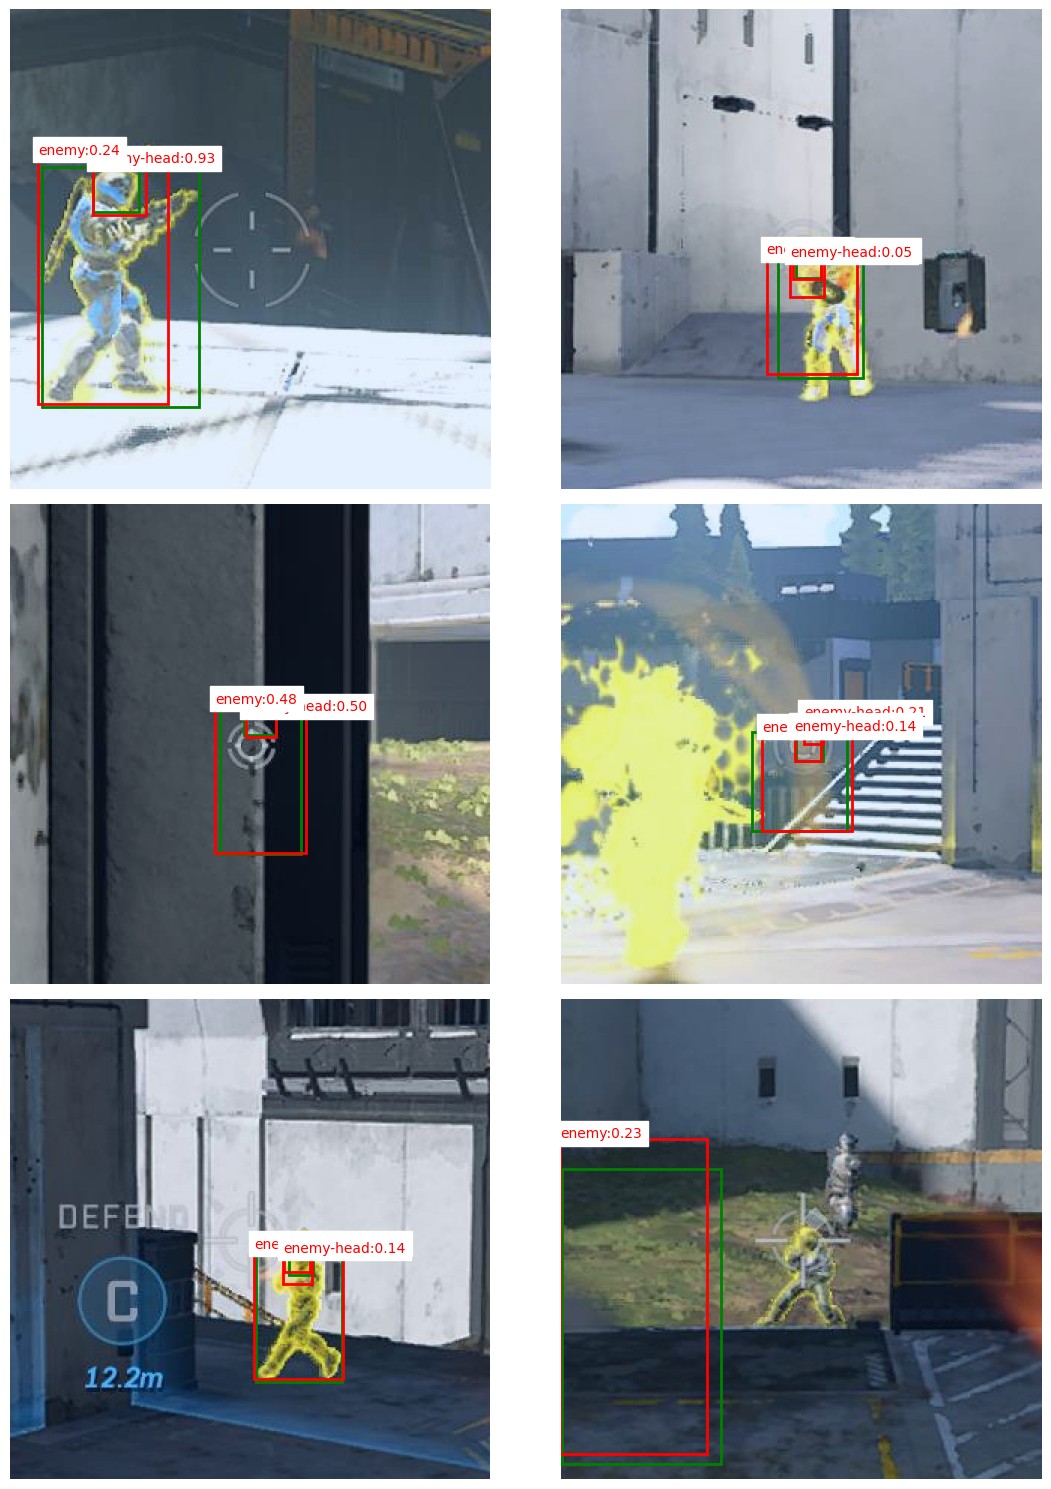

In [41]:
visualize_predictions_grid(model, val_dataloader, device, class_to_name, num_images=6)